<a href="https://colab.research.google.com/github/MajidSharaf/CampaignLens/blob/main/Pipeline/03_SentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1: load cleaned data from step 1

In [1]:
!wget "https://raw.githubusercontent.com/MajidSharaf/CampaignLens/main/Datasets/Versions/comments_cleaned.csv"

--2026-06-13 09:16:39--  https://raw.githubusercontent.com/MajidSharaf/CampaignLens/main/Datasets/Versions/comments_cleaned.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2299025 (2.2M) [text/plain]
Saving to: ‘comments_cleaned.csv.2’

comments_cleaned.cs 100%[===================>]   2.19M  --.-KB/s    in 0.07s   

2026-06-13 09:16:39 (33.4 MB/s) - ‘comments_cleaned.csv.2’ saved [2299025/2299025]



In [2]:
import pandas as pd
import numpy as np
from tqdm import tqdm
tqdm.pandas()

In [3]:
df = pd.read_csv("/content/comments_cleaned.csv")
print(len(df))
df.head()

22174


,cleaned_text
0,not_want news google
1,trump dumbest president american history terri...
2,fareed know full well reason many objected jcp...
3,china 's xinjiang genocide million visited xin...
4,jet pilot need precision


Part 2: VADER

VADER is a rule-based sentiment tool designed for social media, it returns a compound score from -1 to +1.

In [4]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [5]:
analyzer = SentimentIntensityAnalyzer()

def getVaderSentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 1   # positive
    elif score <= -0.05:
        return -1  # negative
    else:
        return 0   # neutral

df["Vader"] = df["cleaned_text"].progress_apply(getVaderSentiment)
print(df["Vader"].value_counts())

100%|██████████| 22174/22174 [00:02<00:00, 8224.77it/s]

Vader
 1    10759
-1     6123
 0     5292
Name: count, dtype: int64


Part 3: RoBERTa

RoBERTa is a transformer model fine-tuned on tweets, it understands full sentence context unlike VADER.

In [6]:
from transformers import pipeline

tweet_model = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    truncation=True,
    max_length=512
)

def getRoBERTaSentiment(text):
    result = tweet_model(text)[0]
    label = result['label']
    if label == 'LABEL_2':
        return 1   # positive
    elif label == 'LABEL_0':
        return -1  # negative
    else:
        return 0   # neutral

# test on 5 comments first
for i, comment in enumerate(df["cleaned_text"][:5]):
    print(f"Comment {i+1}: {comment}")
    print(f"Sentiment: {getRoBERTaSentiment(comment)}\n")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Comment 1: not_want news google
Sentiment: -1

Comment 2: trump dumbest president american history terrible rollemodel america 's young people nothing violence stupidity lie
Sentiment: -1

Comment 3: fareed know full well reason many objected jcpoa lifting sanction coupled sunset clause put iran world 's foremost sponsor terrorism legal funded path acquiring nuclear weapon pretend issue legitimized islamist regime disengenuous attempt lend credence embarrassment agreement outlived usefulness service no longer required
Sentiment: -1

Comment 4: china 's xinjiang genocide million visited xinjiang not_a single photo trace genocide lying farted zenophobia still blatantly smeared china thousand palesteninians dying hand izrale gennozide farted zealot not_blow wind
Sentiment: -1

Comment 5: jet pilot need precision
Sentiment: 0



In [7]:
df["RoBERTa"] = df["cleaned_text"].progress_apply(getRoBERTaSentiment)
print(df["RoBERTa"].value_counts())

100%|██████████| 22174/22174 [52:48<00:00,  7.00it/s]

RoBERTa
 0    10461
-1     7101
 1     4612
Name: count, dtype: int64


VADER saw 48% positive vs RoBERTa's 21%, RoBERTa is more reliable for political and sarcastic text.

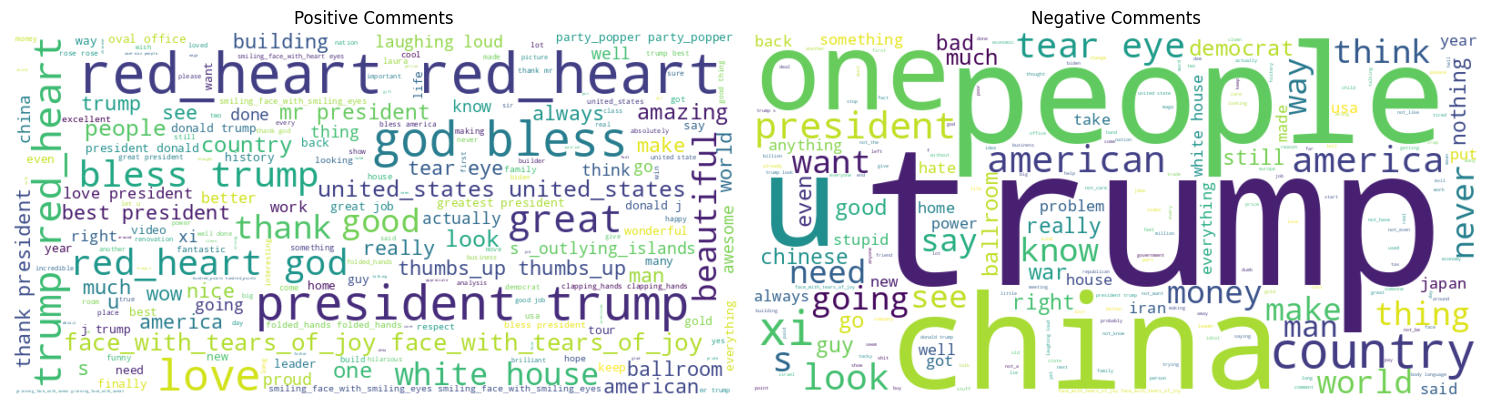

In [8]:
# word cloud for positive and negative comments
!pip install wordcloud -q
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(df[df["RoBERTa"] == 1]["cleaned_text"])
negative_text = " ".join(df[df["RoBERTa"] == -1]["cleaned_text"])

def getWordCloud(text):
    return WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.imshow(getWordCloud(positive_text), interpolation="bilinear")
plt.title("Positive Comments")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(getWordCloud(negative_text), interpolation="bilinear")
plt.title("Negative Comments")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# save sentiment results
df.to_csv('sentiment_results.csv', index=False)
print("Saved! Shape:", df.shape)
print(df.head())

Saved! Shape: (22174, 3)
                                        cleaned_text  Vader  RoBERTa
0                               not_want news google      0       -1
1  trump dumbest president american history terri...     -1       -1
2  fareed know full well reason many objected jcp...     -1       -1
3  china 's xinjiang genocide million visited xin...     -1       -1
4                           jet pilot need precision      0        0
